In [34]:
from manim import *
import manim_physics as mp
import numpy as np

# Scene 1
Start with a single point charge in an electric field

The manim module is not an IPython extension.


Manim Community v0.19.0

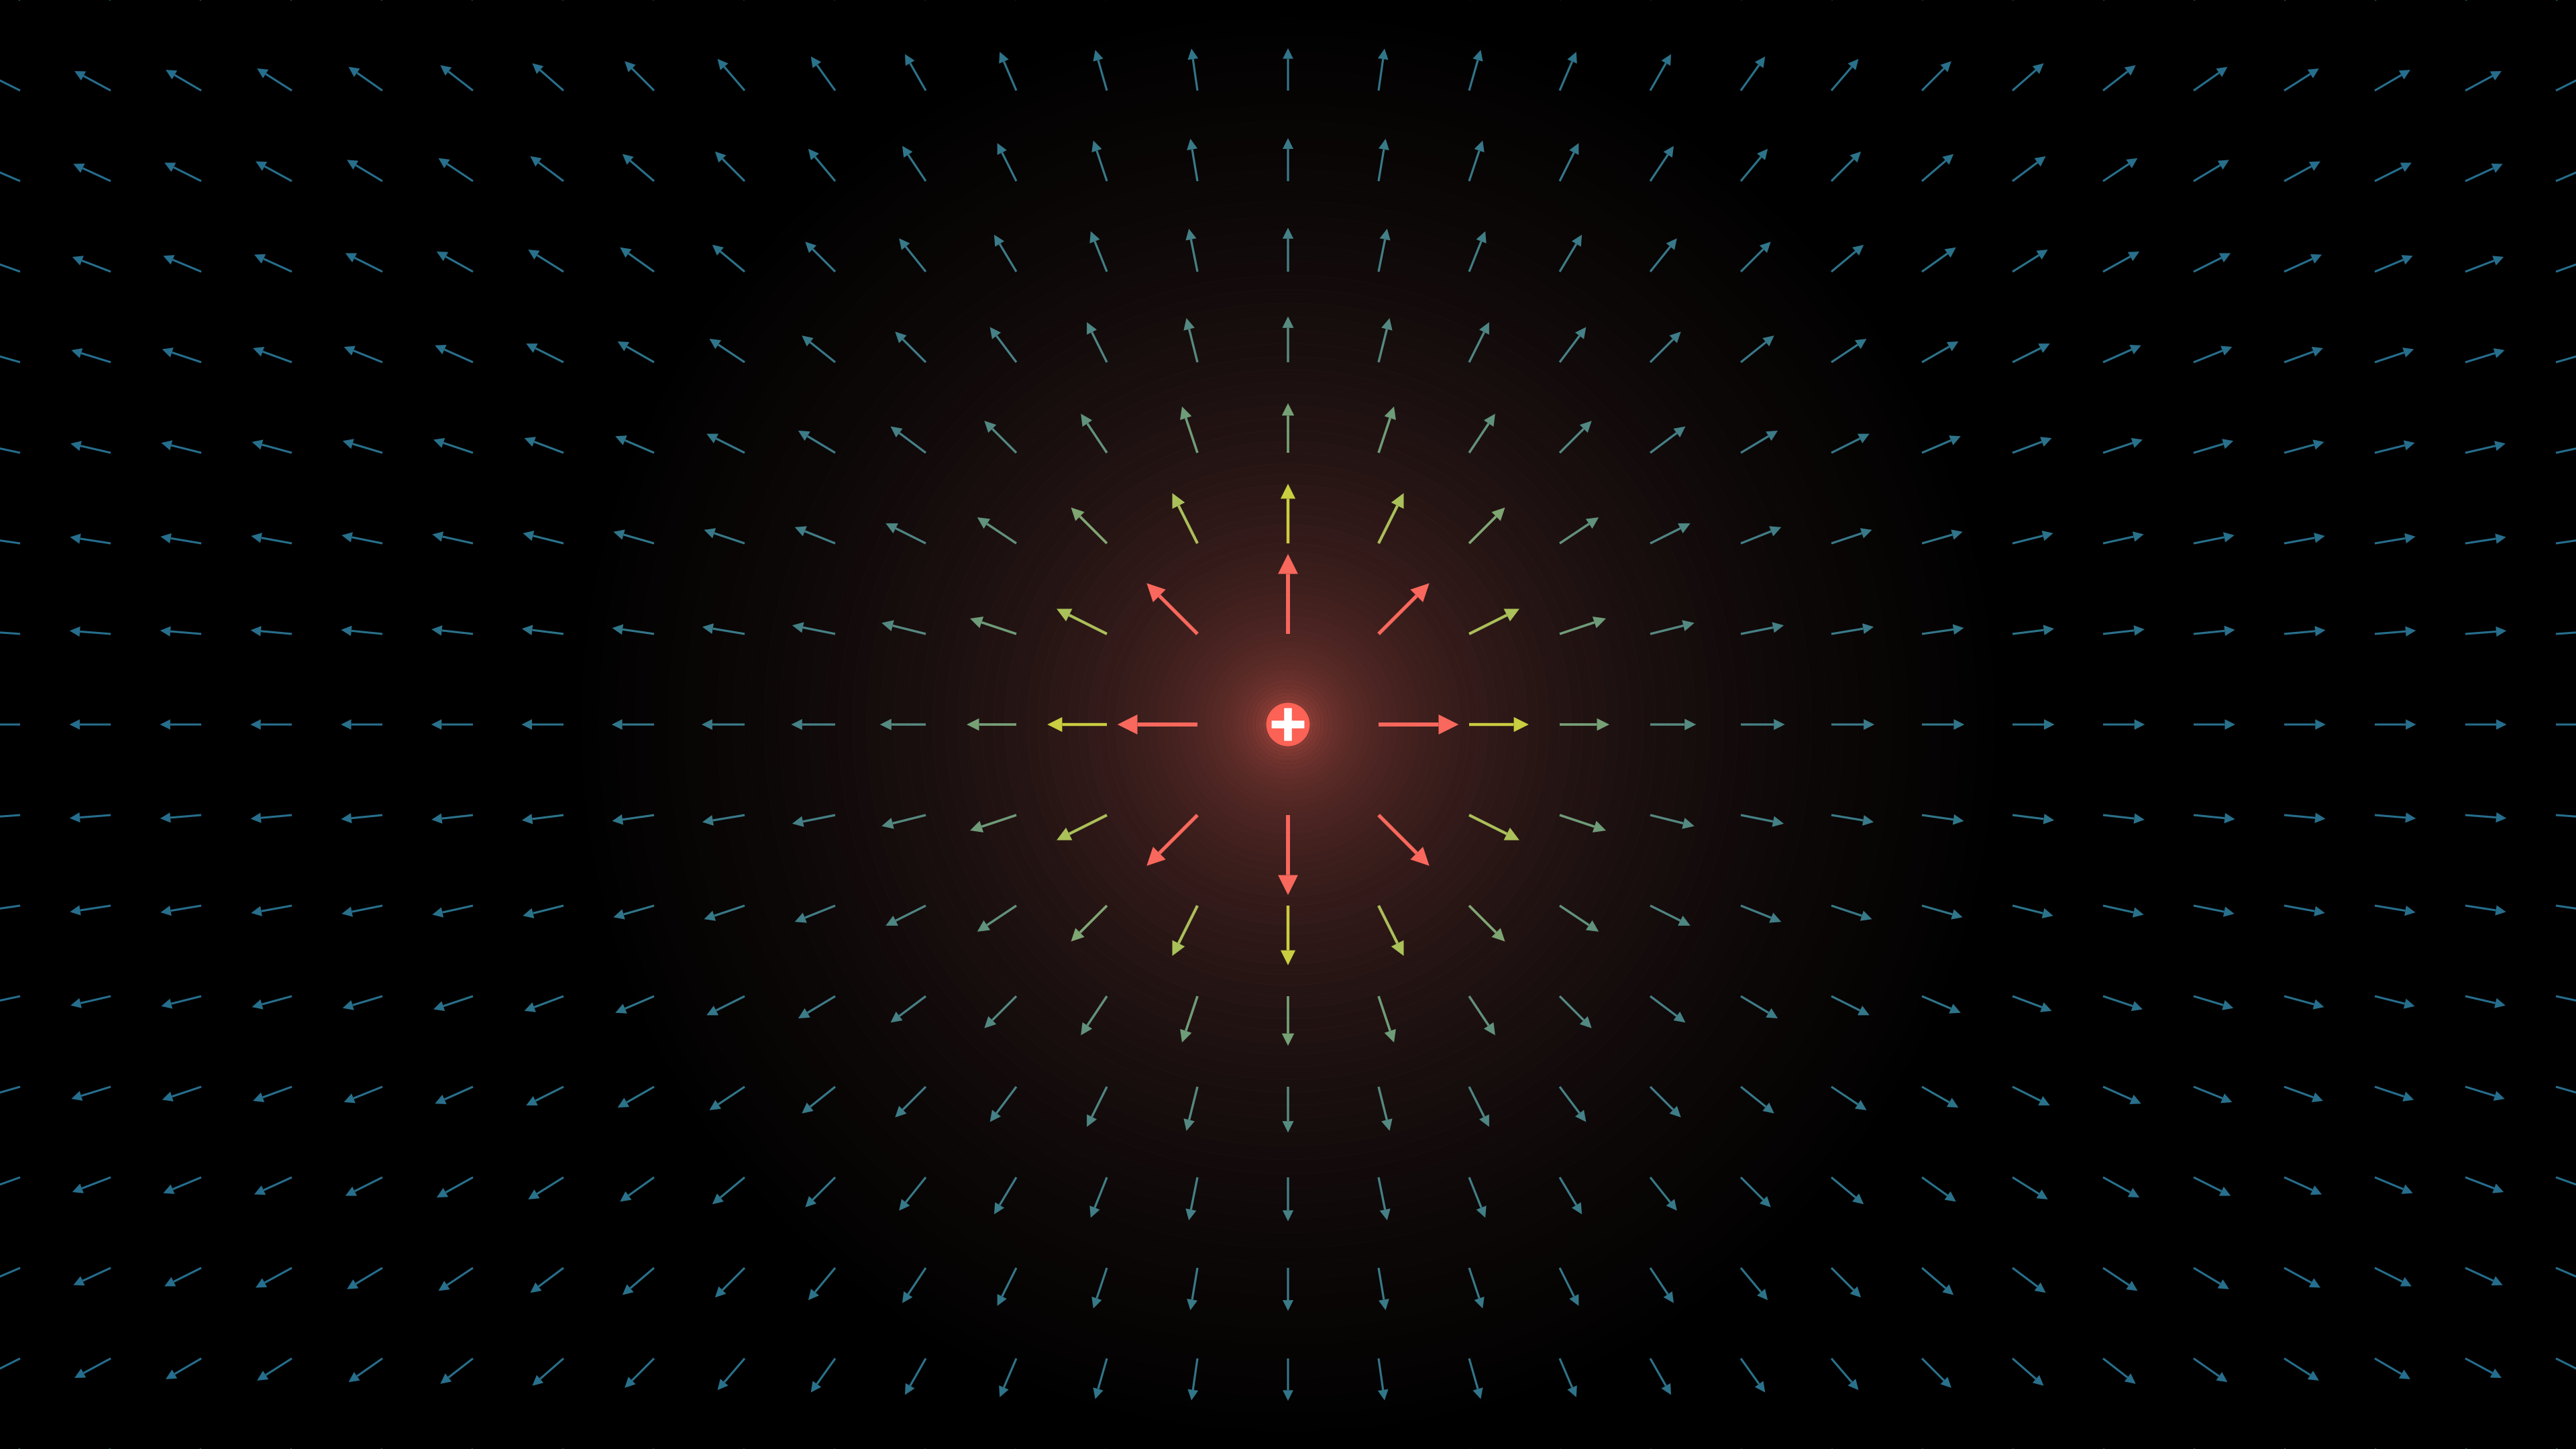

In [35]:
class distribution_s1p1(Scene):
    def construct(self):
        # Create the charge
        charge = mp.Charge(magnitude=1, point=ORIGIN)

        # Create the electric field
        efield = mp.ElectricField(charge)

        # Add the charge and electric field to the scene
        self.add(charge, efield)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s1p1

The manim module is not an IPython extension.


Manim Community v0.19.0

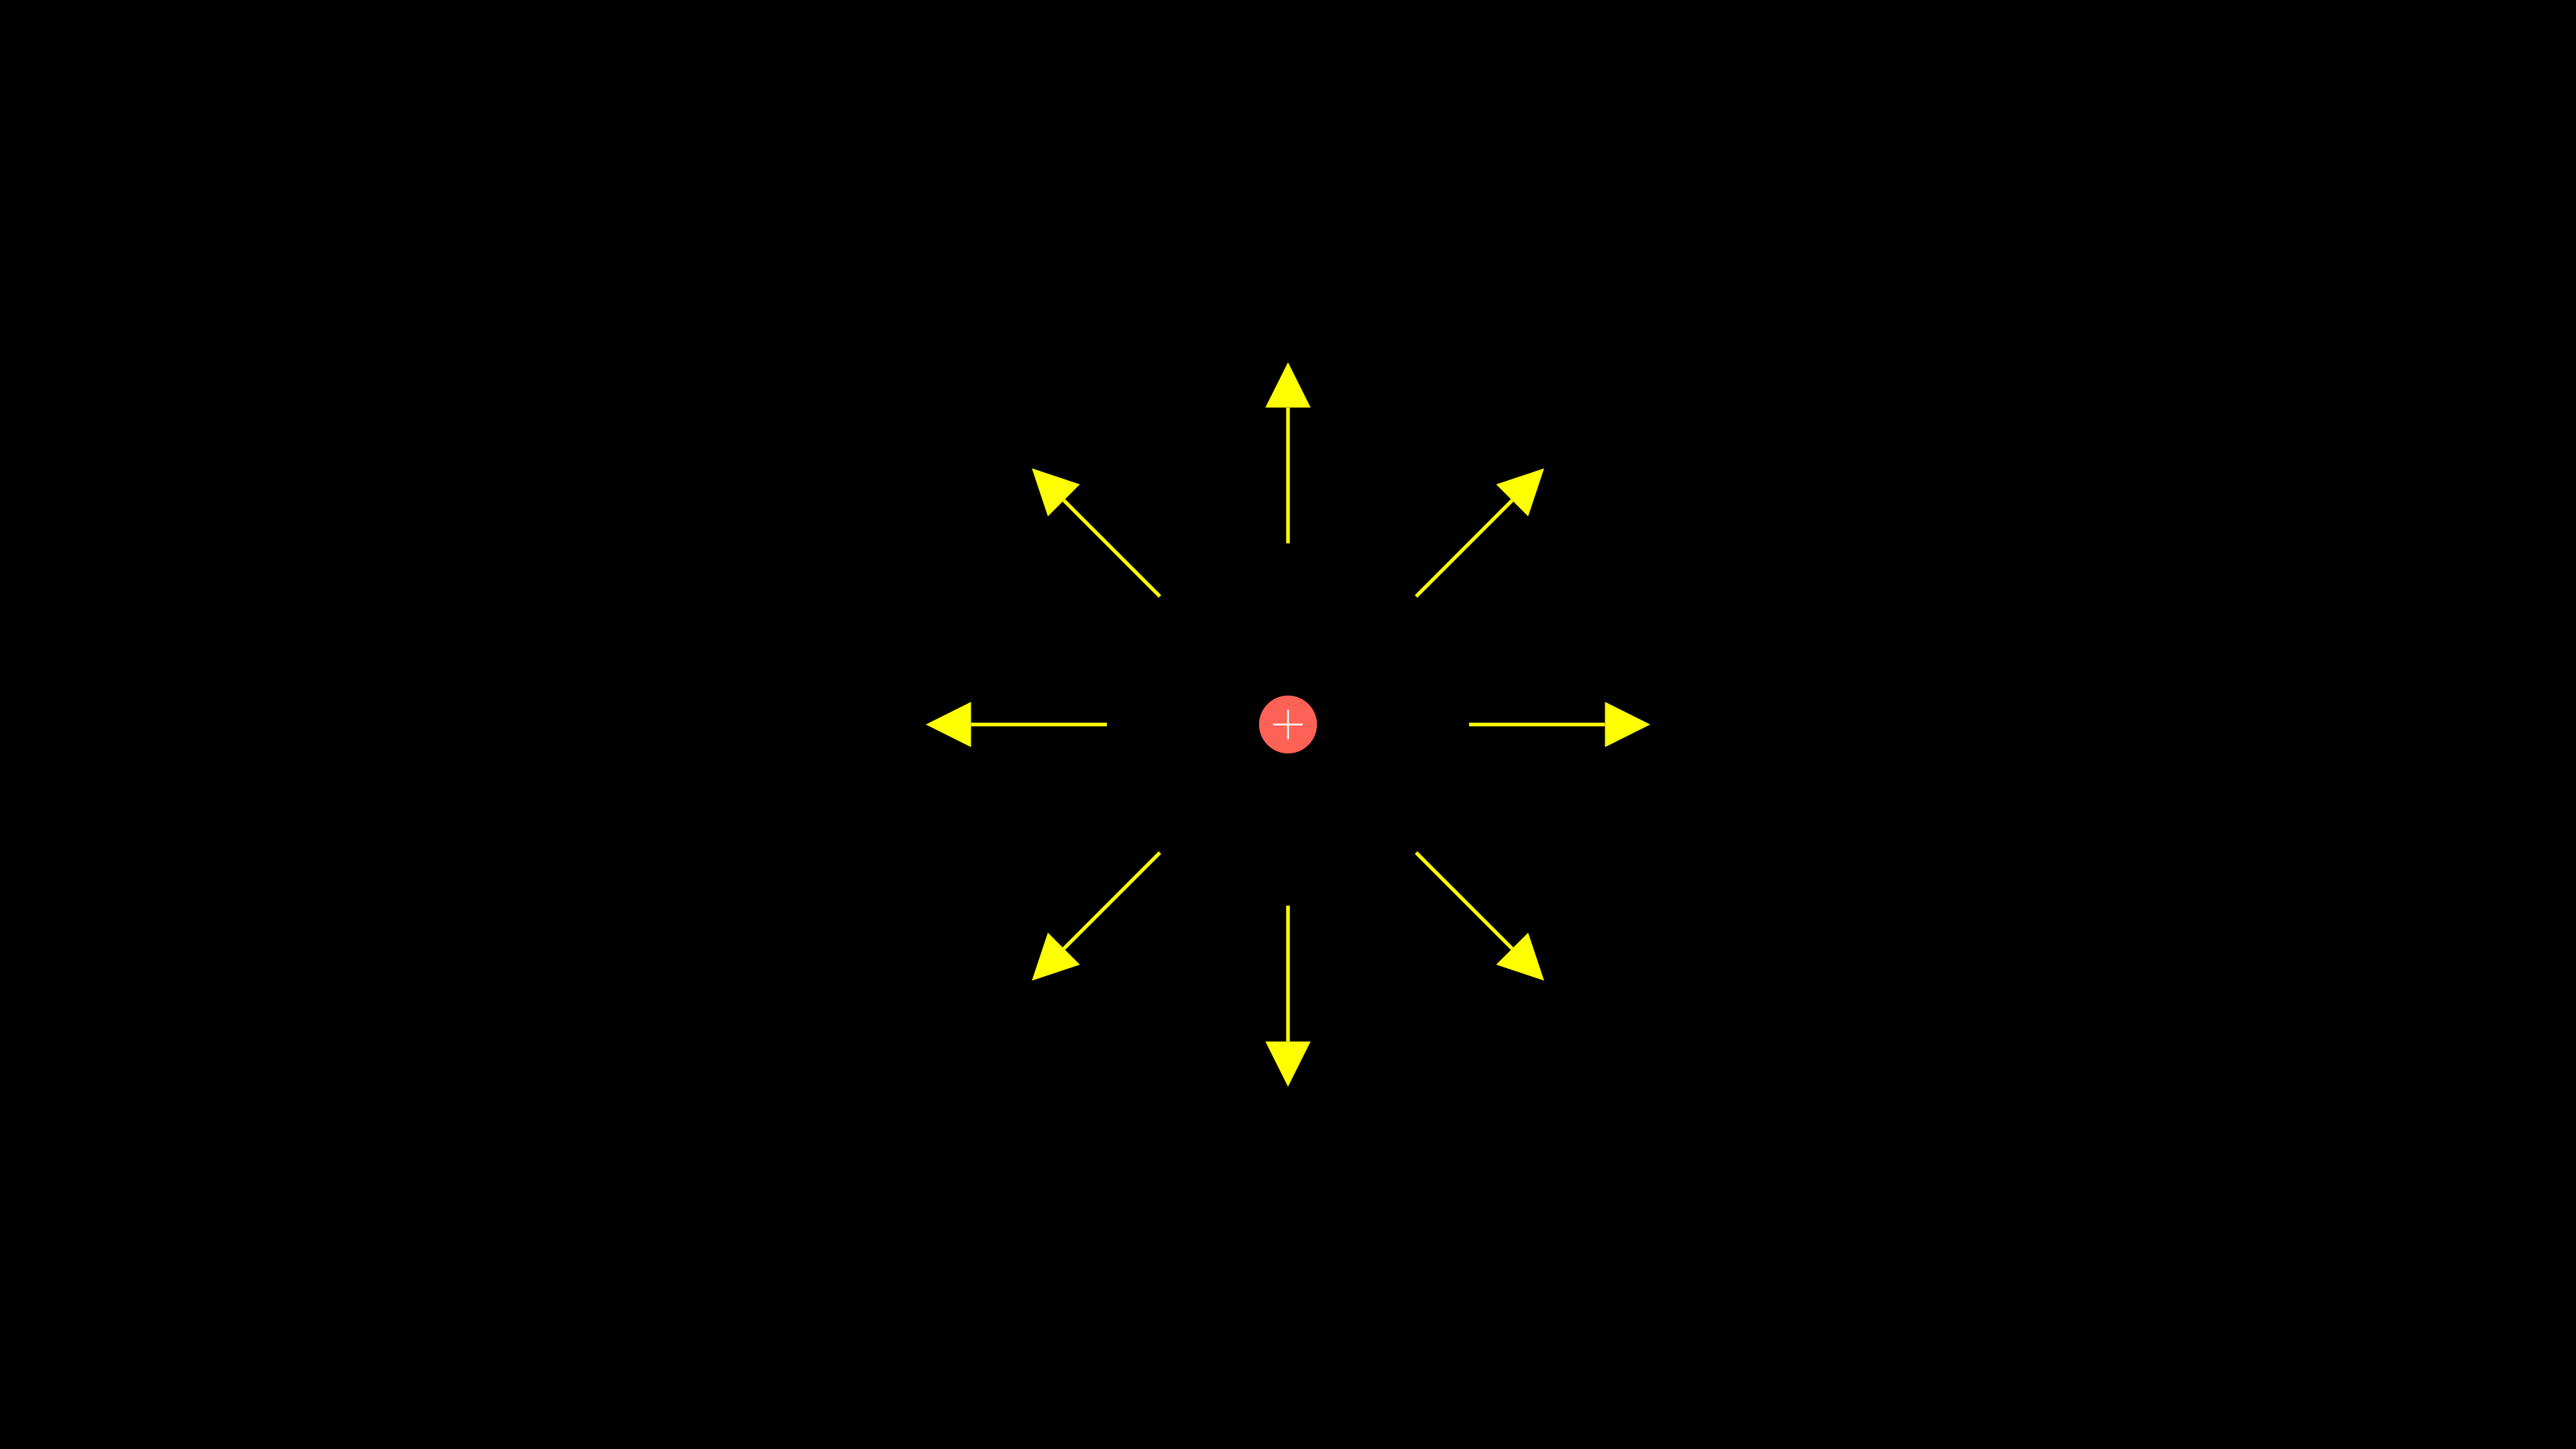

In [36]:
class distribution_s1p1(Scene):
    def construct(self):
        # Create the charge using a circle and plus sign
        positive_charge = Dot(point=ORIGIN, color=RED).scale(2)
        # Add a label for the positive charge
        plus_label = MathTex(r"+", color=WHITE).scale(0.5)
        positive_charge.add(plus_label)

        # Use arrows arranged in a circular pattern to represent the electric field
        num_arrows = 8

        arrows = VGroup()
        for i in range(num_arrows):
            angle = i * TAU / num_arrows  # TAU = 2*pi
            # All arrows start at the center of the circle
            start = np.array([np.cos(angle), np.sin(angle), 0])
            # End point on the circle's edge
            end = 2 * np.array([np.cos(angle), np.sin(angle), 0])
            arrow = Arrow(start, end, buff=0, stroke_width=2, color=YELLOW)
            arrows.add(arrow)


        # Add the charge to the scene
        self.add(positive_charge, arrows)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s1p1

# Scene 1 Negative
Recreate the scene but with a negative charge

The manim module is not an IPython extension.


Manim Community v0.19.0

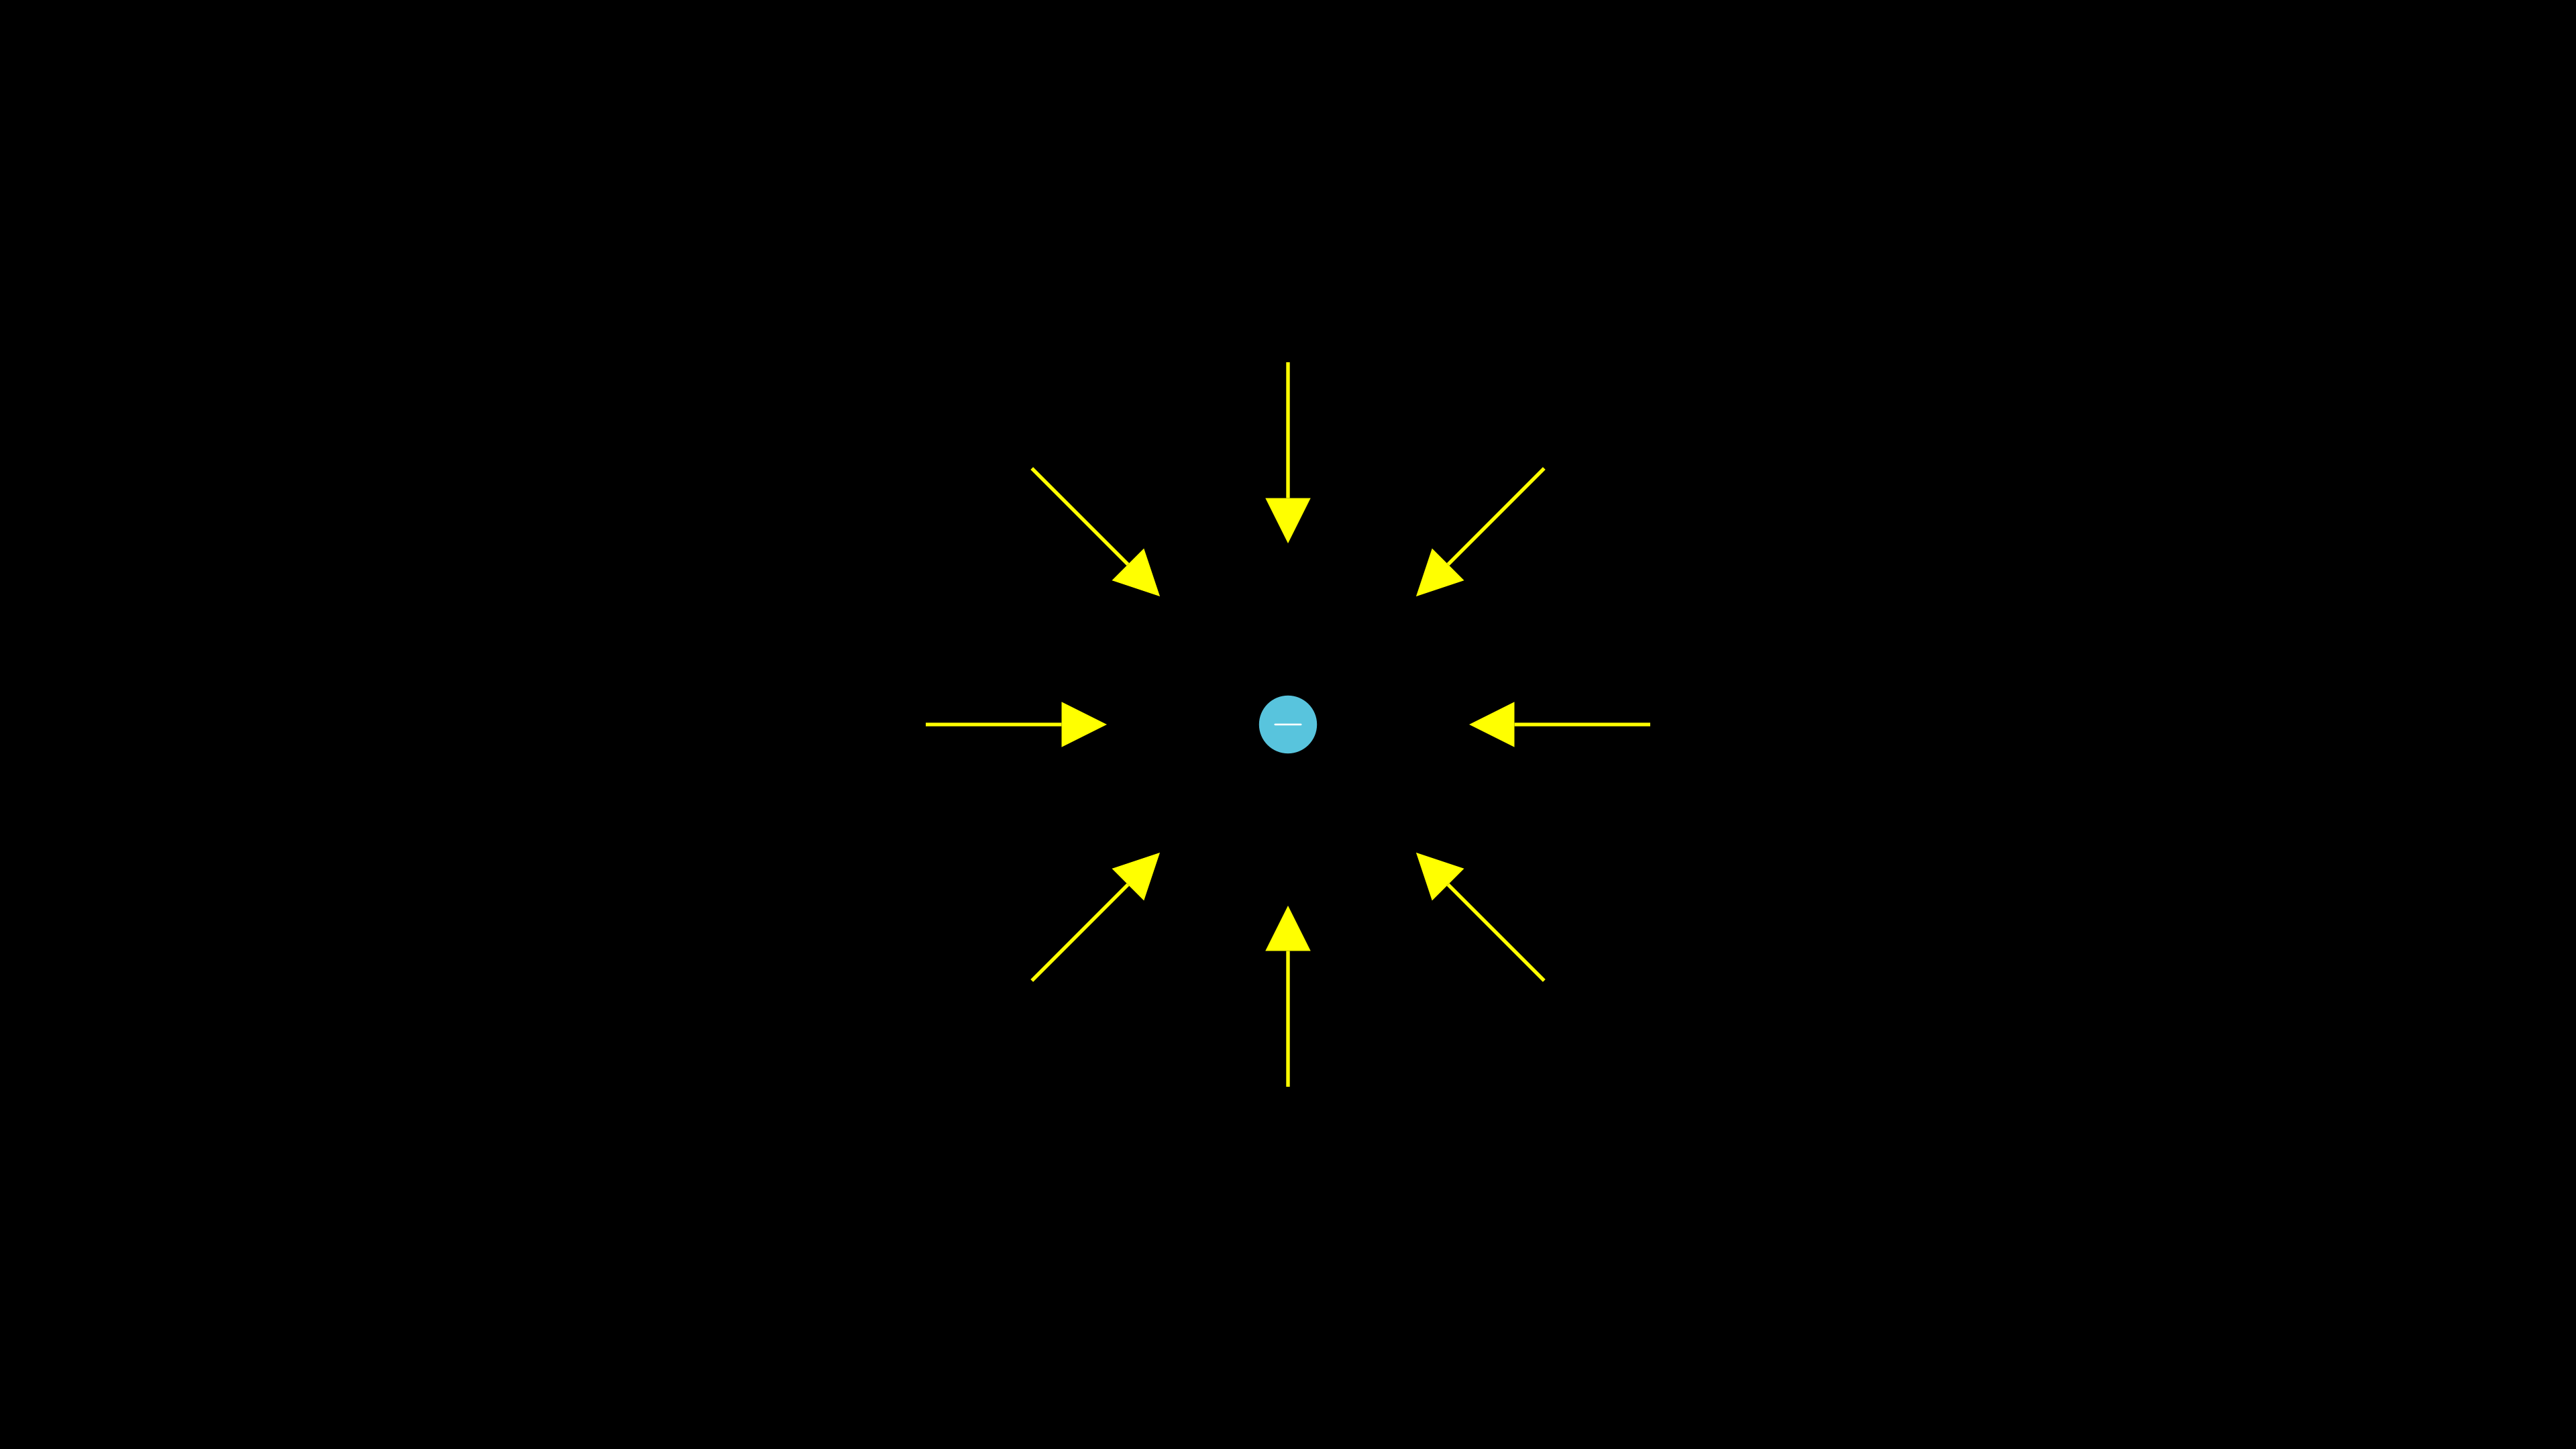

In [37]:
class distribution_s1p2(Scene):
    def construct(self):
        # Create the charge using a circle and plus sign
        negative_charge = Dot(point=ORIGIN, color=BLUE).scale(2)
        # Add a label for the positive charge
        minus_label = MathTex(r"-", color=WHITE).scale(0.5)
        negative_charge.add(minus_label)

        # Use arrows arranged in a circular pattern to represent the electric field
        num_arrows = 8

        arrows = VGroup()
        for i in range(num_arrows):
            angle = i * TAU / num_arrows  # TAU = 2*pi
            # Reverse the arrow directions from the positive charge
            start = 2 * np.array([np.cos(angle), np.sin(angle), 0])
            
            end = np.array([np.cos(angle), np.sin(angle), 0])
            arrow = Arrow(start, end, buff=0, stroke_width=2, color=YELLOW)
            arrows.add(arrow)


        # Add the charge to the scene
        self.add(negative_charge, arrows)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s1p2

# Scene 2 Part 1
Place a line of charges and the electric field of the line to simulate a line charge

In [38]:
class distribution_s2p1(Scene):
    def construct(self):
        # -- Step 1: Define properties --
        num_charges = 5
        charge_magnitude = 1.0 # All positive charges
        charge_spacing = 0.5   # Distance between centers of adjacent charges

        # -- Step 2: Create and position charges --
        charges = VGroup() # A VGroup to hold all charges
        
        # Calculate the total length occupied by the charges for centering
        # (num_charges - 1) * charge_spacing gives total span
        total_span = (num_charges - 1) * charge_spacing
        
        # Start position to center the line of charges
        start_x = -total_span / 2

        for i in range(num_charges):
            x_position = start_x + i * charge_spacing
            
            charge = mp.Charge(magnitude=charge_magnitude, add_glow=False)
            charge.move_to(RIGHT * x_position)
            
            charges.add(charge)
            self.add(charge) # Add each charge to the scene
            
        self.play(Create(charges)) # Animate creating all charges at once
        self.wait(1)

        # -- Step 3: Create and display the Electric Field --
        # The ElectricField Mobject takes all charges as arguments
        # length_func helps control the vector lengths for better visualization
        electric_field = mp.ElectricField(*charges)
        
        # Animate the creation of the electric field
        self.play(FadeIn(electric_field))
        self.wait(3)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s2p1

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 2 Part 2
Turn the Manim Physics field lines into standard Manim arrows

In [39]:
class distribution_s2p2(Scene):
    def construct(self):
        # -- Step 1: Define properties --
        num_charges = 5
        charge_magnitude = 1.0 # All positive charges
        charge_spacing = 0.5   # Distance between centers of adjacent charges

        # -- Step 2: Create and position charges --
        charges = VGroup() # A VGroup to hold all charges
        
        # Calculate the total length occupied by the charges for centering
        # (num_charges - 1) * charge_spacing gives total span
        total_span = (num_charges - 1) * charge_spacing
        
        # Start position to center the line of charges
        start_x = -total_span / 2

        for i in range(num_charges):
            x_position = start_x + i * charge_spacing
            
            charge = mp.Charge(magnitude=charge_magnitude, add_glow=False)
            charge.move_to(RIGHT * x_position)
            
            charges.add(charge)
            self.add(charge) # Add each charge to the scene
            

        # -- Step 3: Create and display the Electric Field --
        # The ElectricField Mobject takes all charges as arguments
        # length_func helps control the vector lengths for better visualization
        electric_field = mp.ElectricField(*charges)
        
        # With everything set up, add the previous scene
        self.add(charges, electric_field)
        self.wait(1)


        # -- Step 4: Transform the field lines into standard arrows --
        # Use arrows arranged in a circular pattern to represent the electric field
        num_eField_lines = 18

        eField_lines = VGroup()
        # Create the arrow part of the electric field
        for i in range(num_eField_lines):
            angle = i * TAU / num_eField_lines  # TAU = 2*pi
            # All arrows start at the center of the circle
            start = charges[2].get_center()  # Centered on the middle charge
            # End point on the circle's edge
            end = 3 * np.array([np.cos(angle), np.sin(angle), 0])
            arrow = Arrow(start, end, buff=0, stroke_width=2, color=YELLOW)
            eField_lines.add(arrow)

        # Create the line part of the electric field
        for i in range(num_eField_lines):
            angle = i * TAU / num_eField_lines  # TAU = 2*pi
            # All arrows start at the center of the circle
            start = charges[2].get_center()  # Centered on the middle charge
            # start = np.array([np.cos(angle), np.sin(angle), 0])
            # End point on the circle's edge
            end = 6 * np.array([np.cos(angle), np.sin(angle), 0])
            line = Line(start, end, stroke_width=1, color=YELLOW)
            eField_lines.add(line)

        # Animate the transformation from field lines to arrows
        self.play(FadeOut(electric_field))
        self.play(FadeIn(eField_lines))
        # self.play(ReplacementTransform(electric_field, arrows))
        self.wait(3)
        

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s2p2

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 2 Part 3
Recreate the scene with negative charges

In [40]:
class distribution_s2p3(Scene):
    def construct(self):
        # -- Step 1: Define properties --
        num_charges = 5
        charge_magnitude = -1.0 # All negative charges
        charge_spacing = 0.5   # Distance between centers of adjacent charges

        # -- Step 2: Create and position charges --
        charges = VGroup() # A VGroup to hold all charges
        
        # Calculate the total length occupied by the charges for centering
        # (num_charges - 1) * charge_spacing gives total span
        total_span = (num_charges - 1) * charge_spacing
        
        # Start position to center the line of charges
        start_x = -total_span / 2

        for i in range(num_charges):
            x_position = start_x + i * charge_spacing
            
            charge = mp.Charge(magnitude=charge_magnitude, add_glow=False)
            charge.move_to(RIGHT * x_position)
            
            charges.add(charge)
            self.add(charge) # Add each charge to the scene
            
        self.play(Create(charges)) # Animate creating all charges at once
        self.wait(1)

        # -- Step 3: Create and display the Electric Field --
        # The ElectricField Mobject takes all charges as arguments
        # length_func helps control the vector lengths for better visualization
        electric_field = mp.ElectricField(*charges)
        
        # Animate the creation of the electric field
        self.play(FadeIn(electric_field))
        self.wait(3)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s2p3

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 2 Part 4
Swap out the eField for arrows again

Need to change the end points for the arrows as they all bunch up at the center for now

In [41]:
class distribution_s2p4(Scene):
    def construct(self):
        # -- Step 1: Define properties --
        num_charges = 5
        charge_magnitude = -1.0 # All positive charges
        charge_spacing = 0.5   # Distance between centers of adjacent charges

        # -- Step 2: Create and position charges --
        charges = VGroup() # A VGroup to hold all charges
        
        # Calculate the total length occupied by the charges for centering
        # (num_charges - 1) * charge_spacing gives total span
        total_span = (num_charges - 1) * charge_spacing
        
        # Start position to center the line of charges
        start_x = -total_span / 2

        for i in range(num_charges):
            x_position = start_x + i * charge_spacing
            
            charge = mp.Charge(magnitude=charge_magnitude, add_glow=False)
            charge.move_to(RIGHT * x_position)
            
            charges.add(charge)
            self.add(charge) # Add each charge to the scene
            

        # -- Step 3: Create and display the Electric Field --
        # The ElectricField Mobject takes all charges as arguments
        # length_func helps control the vector lengths for better visualization
        electric_field = mp.ElectricField(*charges)
        
        # With everything set up, add the previous scene
        self.add(charges, electric_field)
        self.wait(1)


        # -- Step 4: Transform the field lines into standard arrows --
        # Use arrows arranged in a circular pattern to represent the electric field
        num_eField_lines = 18

        eField_lines = VGroup()
        # Create the arrow part of the electric field
        for i in range(num_eField_lines):
            angle = i * TAU / num_eField_lines  # TAU = 2*pi
            # Swap the arrow directions from the positive charge
            start = 3 * np.array([np.cos(angle), np.sin(angle), 0])

            end = charges[2].get_center()  # Centered on the middle charge
            arrow = Arrow(start, end, buff=0, stroke_width=2, color=YELLOW)
            eField_lines.add(arrow)

        # Create the line part of the electric field -- Same as before
        for i in range(num_eField_lines):
            angle = i * TAU / num_eField_lines  # TAU = 2*pi
            # All arrows start at the center of the circle
            start = charges[2].get_center()  # Centered on the middle charge
            # start = np.array([np.cos(angle), np.sin(angle), 0])
            # End point on the circle's edge
            end = 6 * np.array([np.cos(angle), np.sin(angle), 0])
            line = Line(start, end, stroke_width=1, color=YELLOW)
            eField_lines.add(line)

        # Animate the transformation from field lines to arrows
        self.play(FadeOut(electric_field))
        self.play(FadeIn(eField_lines))
        # self.play(ReplacementTransform(electric_field, arrows))
        self.wait(3)
        

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s2p4

The manim module is not an IPython extension.


Manim Community v0.19.0

In [42]:
from manim import *

class ArrowsOnCircles(Scene):
    def construct(self):
        # -- Step 1: Define properties --
        num_circles = 5
        circle_radius = 0.5
        spacing = 0.2 # Space between circles
        arrow_length = 0.6
        arrow_buff = 0.1 # Distance from circle edge to arrow start

        circles_group = VGroup()
        arrows_group = VGroup() # To manage all arrows

        # -- Step 2: Create and place the first circle and its arrows --
        first_circle = Circle(radius=circle_radius, color=BLUE, fill_opacity=0.8)
        first_circle.move_to(LEFT * (num_circles / 2) * (2 * circle_radius + spacing))
        
        # Create arrows for the first circle
        up_arrow_1 = Arrow(
            start=first_circle.get_top() + UP * arrow_buff, # Start slightly above circle top
            end=first_circle.get_top() + UP * (arrow_buff + arrow_length),
            buff=0, # No buffer from start/end points
            color=GREEN
        )
        down_arrow_1 = Arrow(
            start=first_circle.get_bottom() + DOWN * arrow_buff, # Start slightly below circle bottom
            end=first_circle.get_bottom() + DOWN * (arrow_buff + arrow_length),
            buff=0,
            color=RED
        )
        
        self.play(Create(first_circle), Create(up_arrow_1), Create(down_arrow_1))
        circles_group.add(first_circle)
        arrows_group.add(up_arrow_1, down_arrow_1)
        self.wait(0.5)

        # -- Step 3: Add subsequent circles and their arrows to the right --
        for i in range(1, num_circles):
            last_circle = circles_group[-1]

            new_x_position = last_circle.get_right()[0] + spacing + circle_radius
            
            new_circle = Circle(radius=circle_radius, color=BLUE, fill_opacity=0.8)
            new_circle.move_to(RIGHT * new_x_position)

            # Create arrows for the new circle, relative to its position
            up_arrow = Arrow(
                start=new_circle.get_top() + UP * arrow_buff,
                end=new_circle.get_top() + UP * (arrow_buff + arrow_length),
                buff=0,
                color=GREEN
            )
            down_arrow = Arrow(
                start=new_circle.get_bottom() + DOWN * arrow_buff,
                end=new_circle.get_bottom() + DOWN * (arrow_buff + arrow_length),
                buff=0,
                color=RED
            )

            self.play(Create(new_circle), Create(up_arrow), Create(down_arrow))
            circles_group.add(new_circle)
            arrows_group.add(up_arrow, down_arrow)
            self.wait(0.5)

        self.wait(1)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qm -v WARNING ArrowsOnCircles

The manim module is not an IPython extension.


Manim Community v0.19.0

In [43]:
from manim import *

class DynamicArrowsOnCircles(Scene):
    def construct(self):
        # -- Step 1: Define properties --
        num_circles = 5
        circle_radius = 0.5
        spacing = 0.2 # Space between circles
        arrow_length = 0.6
        arrow_buff = 0.1 # Distance from circle edge to arrow start
        side_arrow_buff = 0.3 # Distance for side arrows from circle edge

        circles_group = VGroup() # To manage all circles

        # -- Step 2: Create and place the first circle --
        first_circle = Circle(radius=circle_radius, color=BLUE, fill_opacity=0.8)
        first_circle.move_to(LEFT * (num_circles / 2) * (2 * circle_radius + spacing))
        
        # Create initial UP/DOWN arrows for the first circle
        up_arrow_1 = Arrow(
            start=first_circle.get_top() + UP * arrow_buff,
            end=first_circle.get_top() + UP * (arrow_buff + arrow_length),
            buff=0, color=GREEN
        )
        down_arrow_1 = Arrow(
            start=first_circle.get_bottom() + DOWN * arrow_buff,
            end=first_circle.get_bottom() + DOWN * (arrow_buff + arrow_length),
            buff=0, color=RED
        )

        # Create the STATIC LEFT arrow (always stays with the first circle)
        left_arrow = Arrow(
            start=first_circle.get_left() + LEFT * side_arrow_buff,
            end=first_circle.get_left() + LEFT * (side_arrow_buff + arrow_length),
            buff=0, color=YELLOW
        )
        
        # Add first circle and its static arrows
        self.play(Create(first_circle), Create(up_arrow_1), Create(down_arrow_1), Create(left_arrow))
        circles_group.add(first_circle)
        self.wait(0.5)

        # -- Step 3: Create the DYNAMIC RIGHT arrow --
        # This arrow will always point from the rightmost circle
        # We need a list to keep track of the rightmost circle
        # We'll initially set 'last_added_circle' to first_circle
        last_added_circle = first_circle 
        
        dynamic_right_arrow = always_redraw(
            lambda: Arrow(
                start=last_added_circle.get_right() + RIGHT * side_arrow_buff,
                end=last_added_circle.get_right() + RIGHT * (side_arrow_buff + arrow_length),
                buff=0, color=ORANGE
            )
        )
        self.add(dynamic_right_arrow) # Add it to the scene

        # -- Step 4: Add subsequent circles and their up/down arrows dynamically --
        for i in range(1, num_circles):
            # No need to get 'last_circle' from VGroup; we have 'last_added_circle'
            
            new_x_position = last_added_circle.get_right()[0] + spacing + circle_radius
            
            new_circle = Circle(radius=circle_radius, color=BLUE, fill_opacity=0.8)
            new_circle.move_to(RIGHT * new_x_position)

            # Create UP/DOWN arrows for the new circle
            up_arrow = Arrow(
                start=new_circle.get_top() + UP * arrow_buff,
                end=new_circle.get_top() + UP * (arrow_buff + arrow_length),
                buff=0, color=GREEN
            )
            down_arrow = Arrow(
                start=new_circle.get_bottom() + DOWN * arrow_buff,
                end=new_circle.get_bottom() + DOWN * (arrow_buff + arrow_length),
                buff=0, color=RED
            )

            # Animate the new circle and its arrows
            self.play(Create(new_circle), Create(up_arrow), Create(down_arrow))
            circles_group.add(new_circle) # Add to group for management

            # Update which circle is the 'last_added_circle'
            last_added_circle = new_circle 
            self.wait(0.5)

        self.wait(1)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qm -v WARNING DynamicArrowsOnCircles

The manim module is not an IPython extension.


Manim Community v0.19.0

In [44]:
from manim import *

class GrowingArrowsOnCircles(Scene):
    def construct(self):
        # -- Step 1: Define properties --
        num_circles = 5
        circle_radius = 0.5
        spacing = 0.2
        arrow_length = 0.5 # Start a bit smaller
        arrow_buff = 0.1
        side_arrow_buff = 0.3
        scale_factor = 1.15 # How much to grow each time (1.15 = 15% bigger)

        # This VGroup will hold every arrow in the scene
        all_arrows = VGroup()

        # -- Step 2: Create and place the first circle and its arrows --
        first_circle = Circle(radius=circle_radius, color=BLUE, fill_opacity=0.8)
        first_circle.move_to(LEFT * (num_circles / 2) * (2 * circle_radius + spacing))
        
        up_arrow_1 = Arrow(start=first_circle.get_top() + UP*arrow_buff, end=first_circle.get_top() + UP*(arrow_buff+arrow_length), buff=0, color=GREEN)
        down_arrow_1 = Arrow(start=first_circle.get_bottom() + DOWN*arrow_buff, end=first_circle.get_bottom() + DOWN*(arrow_buff+arrow_length), buff=0, color=RED)
        left_arrow = Arrow(start=first_circle.get_left() + LEFT*side_arrow_buff, end=first_circle.get_left() + LEFT*(side_arrow_buff+arrow_length), buff=0, color=YELLOW)
        
        # Add the first set of arrows to our main group
        all_arrows.add(up_arrow_1, down_arrow_1, left_arrow)

        self.play(Create(first_circle), Create(all_arrows))
        self.wait(0.5)

        # -- Step 3: Create the DYNAMIC RIGHT arrow --
        last_added_circle = first_circle 
        dynamic_right_arrow = always_redraw(
            lambda: Arrow(
                start=last_added_circle.get_right() + RIGHT * side_arrow_buff,
                end=last_added_circle.get_right() + RIGHT * (side_arrow_buff + arrow_length),
                buff=0, color=ORANGE
            )
        )
        # Add the dynamic arrow to the group as well!
        all_arrows.add(dynamic_right_arrow)
        self.add(dynamic_right_arrow)

        # -- Step 4: Add subsequent circles and scale all existing arrows --
        for i in range(1, num_circles):
            new_x_position = last_added_circle.get_right()[0] + spacing + circle_radius
            new_circle = Circle(radius=circle_radius, color=BLUE, fill_opacity=0.8).move_to(RIGHT * new_x_position)

            up_arrow = Arrow(start=new_circle.get_top() + UP*arrow_buff, end=new_circle.get_top() + UP*(arrow_buff+arrow_length), buff=0, color=GREEN)
            down_arrow = Arrow(start=new_circle.get_bottom() + DOWN*arrow_buff, end=new_circle.get_bottom() + DOWN*(arrow_buff+arrow_length), buff=0, color=RED)
            
            # Create a list of scaling animations for all arrows currently in the group
            scaling_animations = [arrow.animate.scale(scale_factor) for arrow in all_arrows]

            # Play the creation of new objects AND the scaling of old ones at the same time
            self.play(
                Create(new_circle),
                Create(up_arrow),
                Create(down_arrow),
                *scaling_animations # The '*' unpacks the list of animations
            )

            # Now add the newly created arrows to the group for the *next* iteration
            all_arrows.add(up_arrow, down_arrow)
            last_added_circle = new_circle 
            self.wait(0.5)

        self.wait(2)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qm -v WARNING GrowingArrowsOnCircles

The manim module is not an IPython extension.


Manim Community v0.19.0

In [45]:
class distribution_s2p2(Scene):
    def construct(self):
        # -- Step 1: Define properties --
        num_circles = 6
        circle_radius = 0.5
        spacing = 0.2 # Space between circles

        charge_group = VGroup()

        # -- Step 2: Create and place the first circle --
        # Start the first charge to the far left of where the line will be
        first_circle_base = Circle(radius=circle_radius, color=RED, fill_opacity=0.8)
        plus_label = MathTex(r"+", color=WHITE).scale(circle_radius*3)
        first_positive_charge = VGroup(first_circle_base, plus_label)
        # Position it so the group will roughly be centered later
        first_positive_charge.move_to(LEFT * (num_circles / 2) * (2 * circle_radius + spacing))
        
        self.play(Create(first_positive_charge))
        charge_group.add(first_positive_charge)
        self.wait(0.5)

        # -- Step 3: Add subsequent circles to the right --
        for i in range(1, num_circles):
            # Get the last circle added to the group
            last_circle = charge_group[-1]

            # Calculate the position for the new circle
            # It should be to the right of the last circle
            # Distance = (last_circle_radius + spacing + new_circle_radius)
            new_x_position = last_circle.get_right()[0] + spacing + circle_radius
            
            new_circle_base = Circle(radius=circle_radius, color=RED, fill_opacity=0.8)
            new_postive_charge = VGroup(new_circle_base, MathTex(r"+", color=WHITE).scale(circle_radius*3))
            new_postive_charge.move_to(RIGHT * new_x_position)

            self.play(Create(new_postive_charge))
            charge_group.add(new_postive_charge)
            self.wait(0.5)

        self.wait(1)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qm -v WARNING distribution_s2p2

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 2 Part 5
Line charge density Equation

The manim module is not an IPython extension.


Manim Community v0.19.0

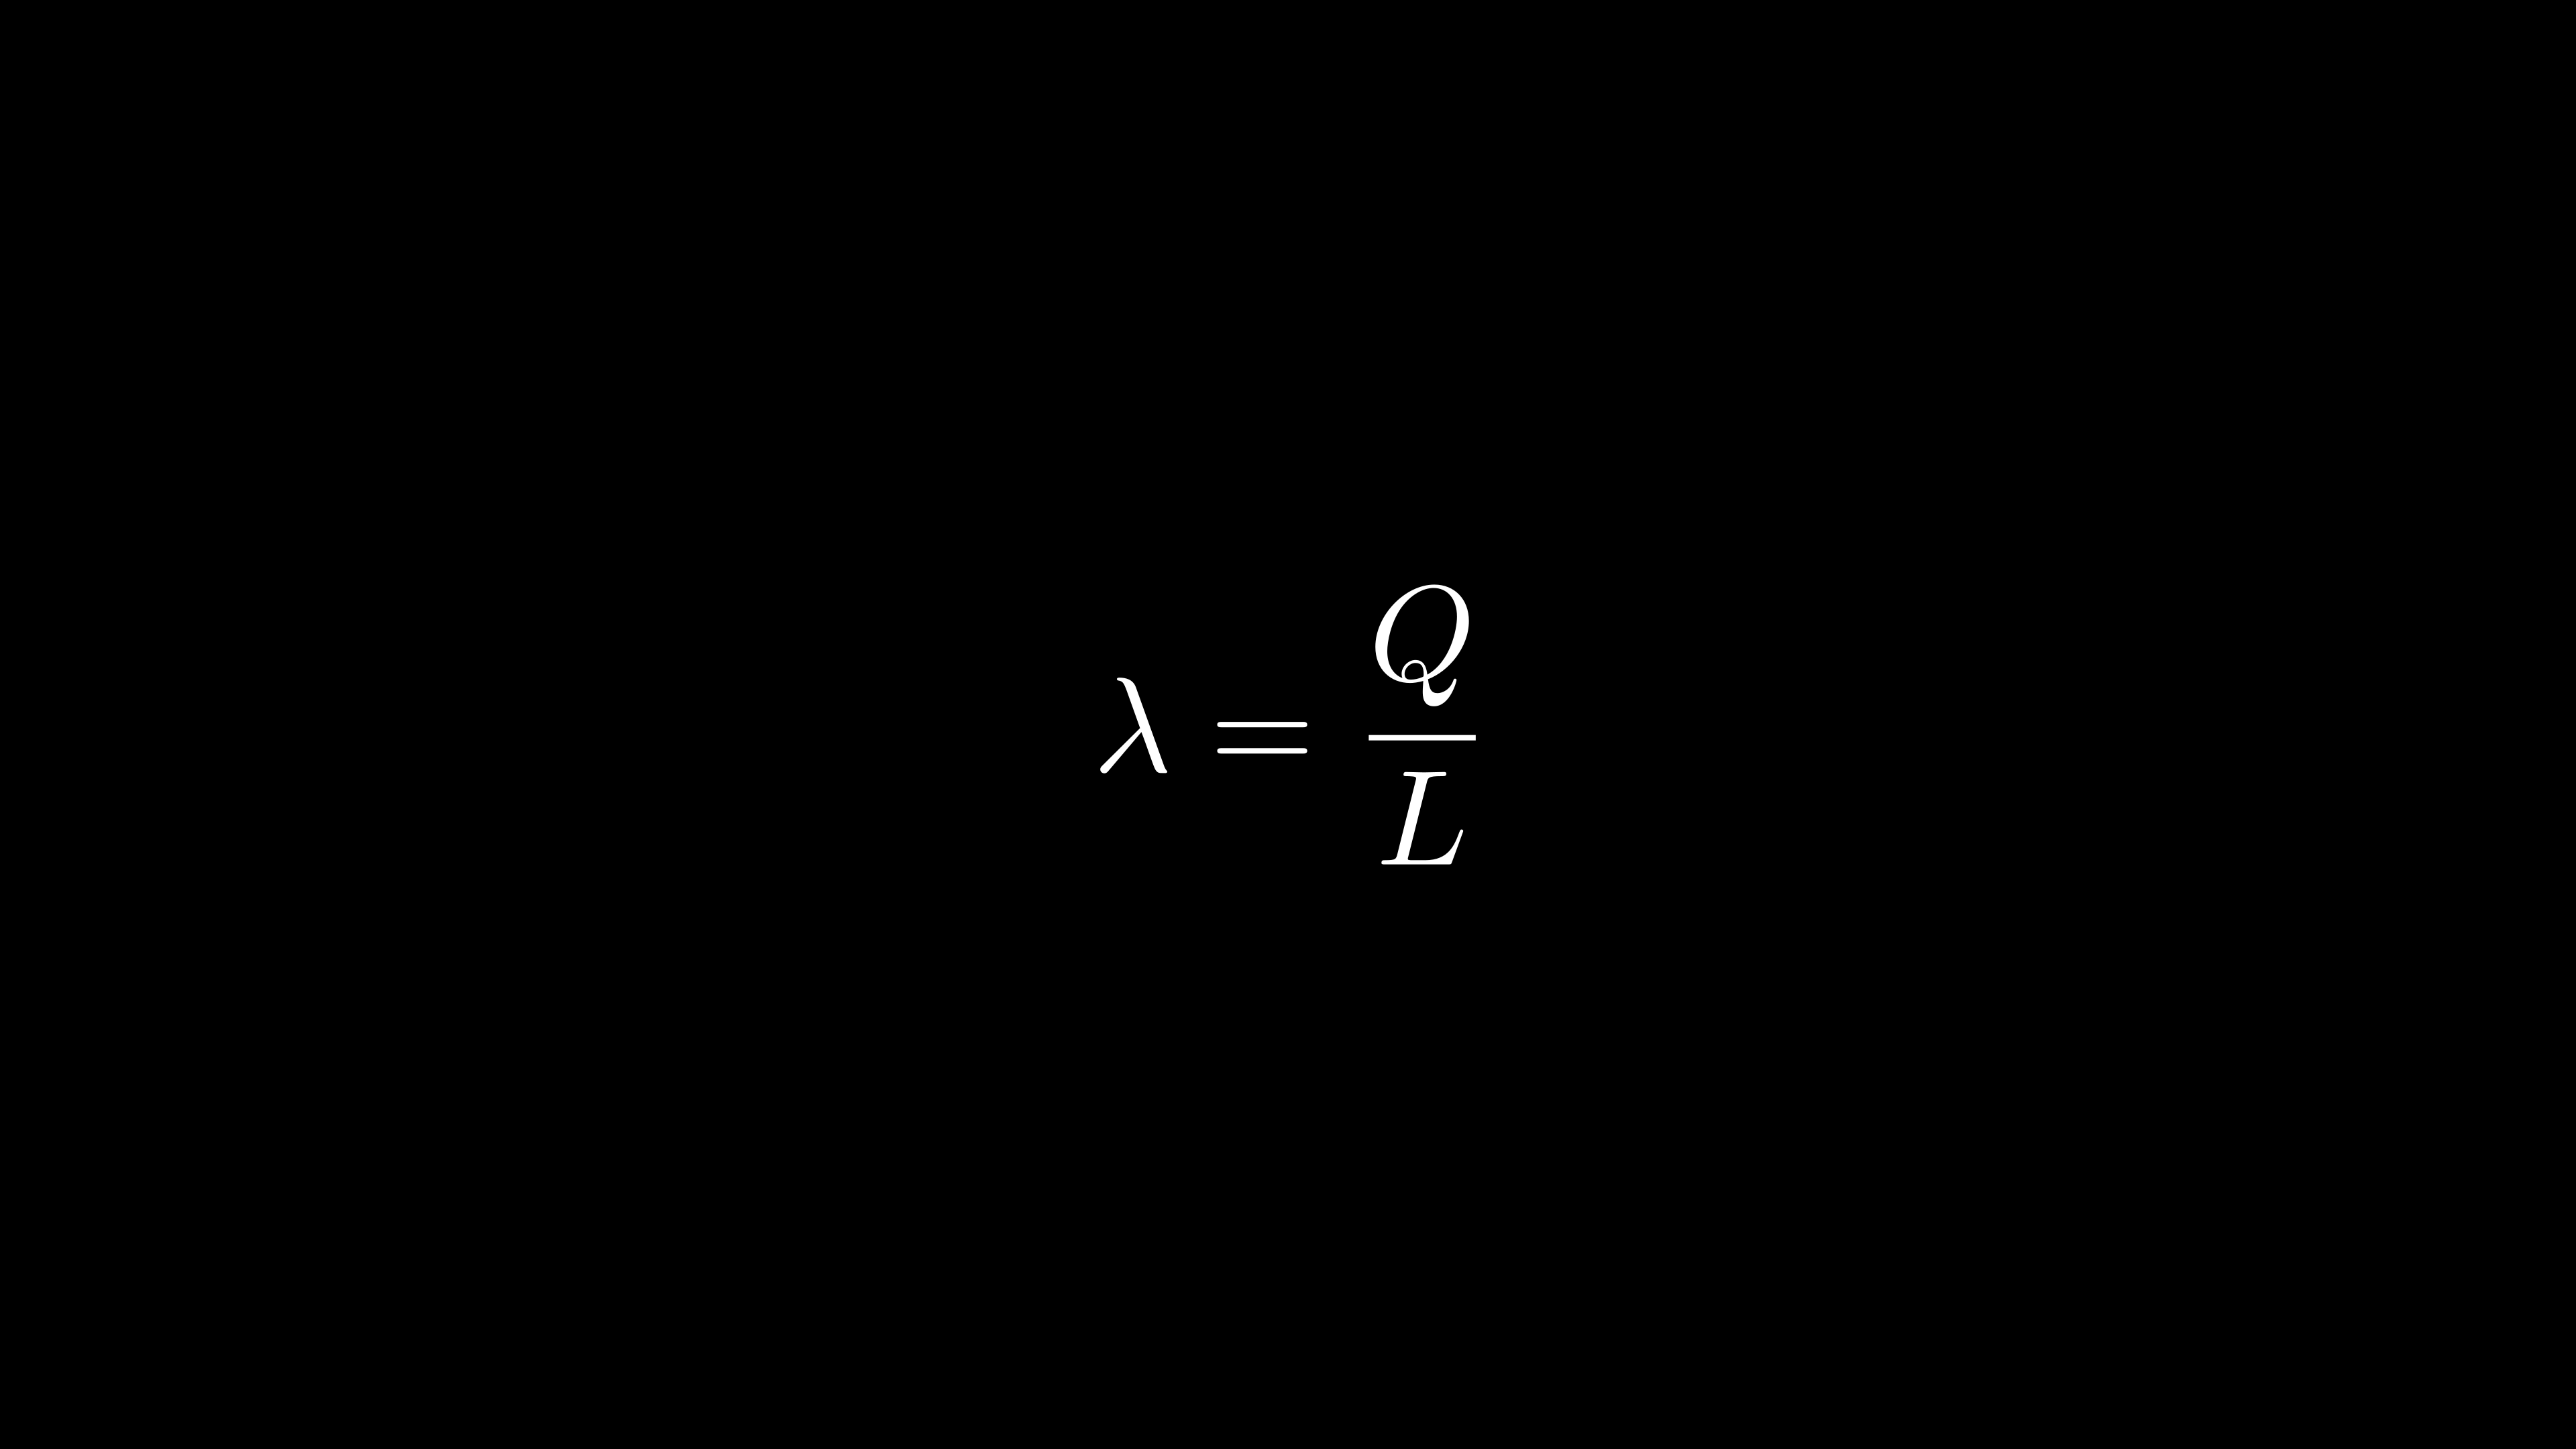

In [46]:
class distribution_s2p5(Scene):
    def construct(self):
        # Create the Line Charge Density equation
        equation = MathTex(r"\lambda = \frac{Q}{L}").scale(1.5)

        # Position the equation at the center of the scene
        equation.move_to(ORIGIN)

        # Add the equation to the scene
        self.add(equation)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s2p5

# Scene 3 Part 1
Create a circle of Charge

In [54]:
from manim import *
import numpy as np

class distribution_s3p1(Scene):
    def construct(self):
        # 1. Define Parameters
        large_radius = 3.5
        small_radius = 0.25
        
        # 2. Create the outer circle
        large_circle = Circle(radius=large_radius, color=BLUE, stroke_width=8)
        
        # 3. Create a VGroup to hold all the small circles
        charges = VGroup()
        
        # Define the spacing between small circles
        spacing = 2 * small_radius * 0.9 # 0.9 gives a little overlap

        # 4. Loop through a grid of positions
        # We use np.arange to create a sequence of numbers for our grid
        x_range = np.arange(-large_radius, large_radius, spacing)
        y_range = np.arange(-large_radius, large_radius, spacing)
        
        for x in x_range:
            for y in y_range:
                # The potential position of the small circle's center
                position = np.array([x, y, 0])
                
                # Boundary Check: Check if the small circle fits inside the large one
                distance_from_center = np.linalg.norm(position)
                if distance_from_center + small_radius < large_radius:
                    # If it fits, create the circle and add it to our VGroup
                    base_charge_circle = Circle(
                        radius=small_radius,
                        color=RED,
                        fill_opacity=1,
                        stroke_width=0.01
                    )
                    # Add a label for the positive charge
                    plus_label = MathTex(r"+", color=WHITE).scale(small_radius*3)
                    positive_charge = VGroup(base_charge_circle, plus_label).move_to(position)


                    charges.add(positive_charge)
        
        # 5. Animate everything
        # The lag_ratio makes the circles appear in a nice wave effect
        self.play(FadeIn(charges, lag_ratio=0.005, run_time=3))
        self.wait(2)
        self.play(Create(large_circle))
        self.wait(0.5)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s3p1

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 3 Part 2
The circle full of charge acts like 1 massive charge, therefore transform into 1 big charge

In [48]:
from manim import *
import numpy as np

class distribution_s3p2(Scene):
    def construct(self):
        # 1. Define Parameters
        large_radius = 3.5
        small_radius = 0.25
        
        # 2. Create the outer circle
        large_circle = Circle(radius=large_radius, color=BLUE, stroke_width=8)
        
        # 3. Create a VGroup to hold all the small circles
        charges = VGroup()
        
        # Define the spacing between small circles
        spacing = 2 * small_radius * 0.9 # 0.9 gives a little overlap

        # 4. Loop through a grid of positions
        # We use np.arange to create a sequence of numbers for our grid
        x_range = np.arange(-large_radius, large_radius, spacing)
        y_range = np.arange(-large_radius, large_radius, spacing)
        
        for x in x_range:
            for y in y_range:
                # The potential position of the small circle's center
                position = np.array([x, y, 0])
                
                # Boundary Check: Check if the small circle fits inside the large one
                distance_from_center = np.linalg.norm(position)
                if distance_from_center + small_radius < large_radius:
                    # If it fits, create the circle and add it to our VGroup
                    base_charge_circle = Circle(
                        radius=small_radius,
                        color=RED,
                        fill_opacity=1,
                        stroke_width=0.01
                    )
                    # Add a label for the positive charge
                    plus_label = MathTex(r"+", color=WHITE).scale(small_radius*3)
                    positive_charge = VGroup(base_charge_circle, plus_label).move_to(position)


                    charges.add(positive_charge)
        
        # 5. Add the previous scene
        self.add(large_circle, charges)

        # Create a Vgroup of the large circle and charges
        full_group = VGroup(large_circle, charges)

        # Create a single large charge to represent the entire distribution
        big_charge_base = Circle(radius=large_radius, color=RED, stroke_width=8, fill_opacity=1)
        # Add a label for the big charge
        big_plus_label = MathTex(r"+", color=WHITE).scale(large_radius*1.5)
        # Make the Vgroup for the big charge
        big_charge = VGroup(big_charge_base, big_plus_label).move_to(ORIGIN)

        # Animate the transformation from the full group to the big charge
        self.play(ReplacementTransform(full_group, big_charge, run_time=3))
        self.wait(2)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s3p2

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 3 Part 3
Add in the electric field outside the surface charge

In [56]:
from manim import *
import numpy as np

class distribution_s3p3(ZoomedScene):
    def construct(self):
        # 1. Define Parameters
        large_radius = 3.5
        
        # Create a single large charge to represent the entire distribution
        big_charge_base = Circle(radius=large_radius, color=RED, stroke_width=8, fill_opacity=1)
        # Add a label for the big charge
        big_plus_label = MathTex(r"+", color=WHITE).scale(large_radius*1.5)
        # Make the Vgroup for the big charge
        big_charge = VGroup(big_charge_base, big_plus_label).move_to(ORIGIN)

        # Use arrows arranged in a circular pattern to represent the electric field
        num_arrows = 8

        arrows = VGroup()
        for i in range(num_arrows):
            angle = i * TAU / num_arrows  # TAU = 2*pi
            # All arrows start at the center of the circle
            start = (large_radius + 1) * np.array([np.cos(angle), np.sin(angle), 0])
            # End point on the circle's edge
            end = (large_radius * 3) * np.array([np.cos(angle), np.sin(angle), 0])
            arrow = Arrow(start, end, buff=0, stroke_width=2, color=YELLOW)
            arrows.add(arrow)

        # Add the big charge to the scene
        self.add(big_charge)

        # Fade in the electric field arrows
        self.play(FadeIn(arrows, run_time=3))
        self.wait(1)

        # Animate the camera zooming out to show the electric field outside the charge
        self.play(self.camera.frame.animate.scale(3), run_time=2)
        self.wait(2)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s3p3

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 3 Part 4
Creating a circle of negative charge

In [55]:
from manim import *
import numpy as np

class distribution_s3p4(Scene):
    def construct(self):
        # 1. Define Parameters
        large_radius = 3.5
        small_radius = 0.25
        
        # 2. Create the outer circle
        large_circle = Circle(radius=large_radius, color=WHITE, stroke_width=8)
        
        # 3. Create a VGroup to hold all the small circles
        charges = VGroup()
        
        # Define the spacing between small circles
        spacing = 2 * small_radius * 0.9 # 0.9 gives a little overlap

        # 4. Loop through a grid of positions
        # We use np.arange to create a sequence of numbers for our grid
        x_range = np.arange(-large_radius, large_radius, spacing)
        y_range = np.arange(-large_radius, large_radius, spacing)
        
        for x in x_range:
            for y in y_range:
                # The potential position of the small circle's center
                position = np.array([x, y, 0])
                
                # Boundary Check: Check if the small circle fits inside the large one
                distance_from_center = np.linalg.norm(position)
                if distance_from_center + small_radius < large_radius:
                    # If it fits, create the circle and add it to our VGroup
                    base_charge_circle = Circle(
                        radius=small_radius,
                        color=BLUE,
                        fill_opacity=1,
                        stroke_width=0.01
                    )
                    # Add a label for the positive charge
                    negative_label = MathTex(r"-", color=WHITE).scale(small_radius*3)
                    positive_charge = VGroup(base_charge_circle, negative_label).move_to(position)


                    charges.add(positive_charge)
        
        # 5. Animate everything
        # The lag_ratio makes the circles appear in a nice wave effect
        self.play(FadeIn(charges, lag_ratio=0.005, run_time=3))
        self.wait(2)
        self.play(Create(large_circle))
        self.wait(0.5)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s3p4

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 3 Part 5
Turning into a big negative charge

In [51]:
from manim import *
import numpy as np

class distribution_s3p5(Scene):
    def construct(self):
        # 1. Define Parameters
        large_radius = 3.5
        small_radius = 0.25
        
        # 2. Create the outer circle
        large_circle = Circle(radius=large_radius, color=WHITE, stroke_width=8)
        
        # 3. Create a VGroup to hold all the small circles
        charges = VGroup()
        
        # Define the spacing between small circles
        spacing = 2 * small_radius * 0.9 # 0.9 gives a little overlap

        # 4. Loop through a grid of positions
        # We use np.arange to create a sequence of numbers for our grid
        x_range = np.arange(-large_radius, large_radius, spacing)
        y_range = np.arange(-large_radius, large_radius, spacing)
        
        for x in x_range:
            for y in y_range:
                # The potential position of the small circle's center
                position = np.array([x, y, 0])
                
                # Boundary Check: Check if the small circle fits inside the large one
                distance_from_center = np.linalg.norm(position)
                if distance_from_center + small_radius < large_radius:
                    # If it fits, create the circle and add it to our VGroup
                    base_charge_circle = Circle(
                        radius=small_radius,
                        color=BLUE,
                        fill_opacity=1,
                        stroke_width=0.01
                    )
                    # Add a label for the positive charge
                    negative_label = MathTex(r"-", color=WHITE).scale(small_radius*3)
                    positive_charge = VGroup(base_charge_circle, negative_label).move_to(position)


                    charges.add(positive_charge)
        
        # 5. Add the previous scene
        self.add(large_circle, charges)

        # Create a Vgroup of the large circle and charges
        full_group = VGroup(large_circle, charges)

        # Create a single large charge to represent the entire distribution
        big_charge_base = Circle(radius=large_radius, color=BLUE, stroke_width=8, fill_opacity=1)
        # Add a label for the big charge
        big_negative_label = MathTex(r"-", color=WHITE).scale(large_radius*1.5)
        # Make the Vgroup for the big charge
        big_charge = VGroup(big_charge_base, big_negative_label).move_to(ORIGIN)

        # Animate the transformation from the full group to the big charge
        self.play(ReplacementTransform(full_group, big_charge, run_time=3))
        self.wait(2)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s3p5

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 3 Part 6
Create the electric field arrows

In [52]:
from manim import *
import numpy as np

class distribution_s3p6(ZoomedScene):
    def construct(self):
        # 1. Define Parameters
        large_radius = 3.5
        
        # Create a single large charge to represent the entire distribution
        big_charge_base = Circle(radius=large_radius, color=BLUE, stroke_width=8, fill_opacity=1)
        # Add a label for the big charge
        big_negative_label = MathTex(r"-", color=WHITE).scale(large_radius*1.5)
        # Make the Vgroup for the big charge
        big_charge = VGroup(big_charge_base, big_negative_label).move_to(ORIGIN)

        # Use arrows arranged in a circular pattern to represent the electric field
        num_arrows = 8

        arrows = VGroup()
        for i in range(num_arrows):
            angle = i * TAU / num_arrows  # TAU = 2*pi
            # All arrows start at the center of the circle
            start = (large_radius * 3) * np.array([np.cos(angle), np.sin(angle), 0])
            # End point on the circle's edge
            end = (large_radius + 1) * np.array([np.cos(angle), np.sin(angle), 0])
            arrow = Arrow(start, end, buff=0, stroke_width=2, color=YELLOW)
            arrows.add(arrow)

        # Add the big charge to the scene
        self.add(big_charge)

        # Fade in the electric field arrows
        self.play(FadeIn(arrows, run_time=3))
        self.wait(1)

        # Animate the camera zooming out to show the electric field outside the charge
        self.play(self.camera.frame.animate.scale(3), run_time=2)
        self.wait(2)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING distribution_s3p6

The manim module is not an IPython extension.


Manim Community v0.19.0

# Scene 4 Part 1
Going 3D with a sphere of charge

In [53]:
from manim import *
import numpy as np

class distribution_s4p1(ThreeDScene): # Inherit from ThreeDScene for 3D capabilities
    def construct(self):
        # 1. Define Parameters
        large_radius = 3.5
        small_radius = 0.3  # Slightly larger small spheres to fill more volume
        
        # 2. Set up 3D camera orientation
        # We'll view the scene from an angle to appreciate the 3D nature
        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)
        
        # 3. Create the outer sphere
        # Set a low opacity so we can see the inner spheres
        large_sphere = Sphere(radius=large_radius, color=BLUE, resolution=(20, 20))
        large_sphere.set_fill(BLUE, opacity=0.5)
        
        # 4. Create a VGroup to hold all the small spheres
        all_small_spheres = VGroup()
        
        # Define the spacing between small spheres for filling
        spacing = 2 * small_radius * 1.05 # Slightly adjusted for 3D packing

        # 5. Loop through a 3D grid of positions (x, y, z)
        # We'll iterate through a cube that encompasses the large sphere
        grid_range = np.arange(-large_radius, large_radius, spacing)
        
        for x in grid_range:
            for y in grid_range:
                for z in grid_range: # Third loop for the z-dimension
                    position = np.array([x, y, z])
                    
                    # 6. 3D Boundary Check
                    distance_from_center = np.linalg.norm(position) # norm works for 3D vectors
                    
                    # Only add if the small sphere fits completely inside the large one
                    if distance_from_center + small_radius < large_radius:
                        small_sphere = Sphere(
                            radius=small_radius,
                            color=YELLOW,
                            resolution=(10, 10), # Lower resolution for inner spheres, can optimize rendering
                            fill_opacity=1,
                            stroke_width=0 # No stroke for solid spheres
                        ).move_to(position)
                        
                        all_small_spheres.add(small_sphere)
                    
        # 7. Animate everything
        self.play(Create(large_sphere, run_time=2))
        self.wait(0.5)
        # For many 3D objects, a simple FadeIn with lag_ratio works great
        self.play(FadeIn(all_small_spheres, lag_ratio=0.005, run_time=5)) 
        
        # Optional: Rotate the camera to show the 3D effect
        self.begin_ambient_camera_rotation(rate=0.1) # Rotate the camera slowly
        self.wait(5)
        self.stop_ambient_camera_rotation()
        self.wait(1)

# load the manim extension
%load_ext manim

# Render the main scene
%manim -qm -v WARNING distribution_s4p1

The manim module is not an IPython extension.


Manim Community v0.19.0

[10/03/25 15:14:48] WARNING  It looks like the scene contains a lot of sub-mobjects. Caching is      ]8;id=190285;file://c:\Python312\Lib\site-packages\manim\utils\hashing.py\hashing.py]8;;\:]8;id=302214;file://c:\Python312\Lib\site-packages\manim\utils\hashing.py#160\160]8;;\
                             sometimes not suited to handle such large scenes, you might consider                  
                             disabling caching with --disable_caching to potentially speed up the                  
                             rendering process.                                                                    

                    WARNING  You can disable this warning by setting disable_caching_warning to True ]8;id=873963;file://c:\Python312\Lib\site-packages\manim\utils\hashing.py\hashing.py]8;;\:]8;id=421443;file://c:\Python312\Lib\site-packages\manim\utils\hashing.py#166\166]8;;\
                             in your config file.                                                                  

KeyboardInterrupt: 